## Import

In [17]:
import matplotlib, numpy, pandas, scipy, shapely, networkx, astropy, aplpy, lmfit

print("matplotlib", matplotlib.__version__ , '3.10.1')
print("numpy", numpy.__version__, '2.2.5')
print("pandas", pandas.__version__, '2.2.3')
print("scipy", scipy.__version__, '1.15.2')
print("shapely", shapely.__version__, '2.1.0')
print("networkx", networkx.__version__, '3.4.2')
print("astropy", astropy.__version__, '7.0.1')
print("aplpy", aplpy.__version__, '2.2.0')
print("lmfit", lmfit.__version__, '1.3.3')

from analysis import analyse, load, plotter
from analysis import polygons_utility as putility
from analysis import network_utility as utility


import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.dpi'] = 150 

matplotlib 3.10.1 3.10.1
numpy 2.2.5 2.2.5
pandas 2.2.3 2.2.3
scipy 1.15.2 1.15.2
shapely 2.1.0 2.1.0
networkx 3.4.2 3.4.2
astropy 7.0.1 7.0.1
aplpy 2.2.0 2.2.0
lmfit 1.3.3 1.3.3
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Link file (.toml)

In order to link the catalogs with their corresponding parameters and give FAMILY the proper data you need to fill a link file. 

You need to: 
- give the file a name [dataset]
- specity if the sources are elipses or other [object]
- give the path of the catalog and its corresponding fits map [files]
- specify the name of positions, semi major/minor axis, position angle, mass/flux, class (for YSOs) in the catalog [columns_names_in_catalog]
- give the conversion factor in order to convert every position parameter in degree except PA that needs to be in radian [unit_conversion]
- give the information of beam size (in arcsec), wavelength (in microns), distance (in pc), fov_window [observation]

This file will create hyperparameters that will be comparable with the other catalog

In [18]:
from pathlib import Path
import pandas as pd




path = Path("./benchmark/config_simu2026/").resolve()


def reader(x):
    data = pd.read_csv(x, **dict(skip_blank_lines=True, 
                                 header=112, # index of the header (column names)
                                 skiprows=[113,114], # index of the line(s) to skip after the header until the data
                                 engine='python', 
                                 sep="!|\\s+"))
    step = np.sum(np.isnan(np.array(data.iloc[-1] , dtype=np.float64)))
    data = data.shift(periods= step, axis="columns")
    data = data.drop(data.columns[:step], axis=1)
    return data

dataset = analyse.DataSet(
    analyse.Data(config, reader_to_df=reader)
    for config in path.glob("*.toml")
)

for name, data in dataset.items():
    print(f"sample {name} : {len(data.df)} elements")
    
print(f"total #elements = {sum(data.df.size for data in dataset)}")

sample 100AU : 234 elements
sample 8100AU : 13 elements
sample 300AU : 301 elements
sample 2700AU : 43 elements
sample 900AU : 206 elements
total #elements = 23910


# Attributes of Data class

- 'path': path of the config file that is used to read the data
- 'df': normalised dataframe the code reads
- 'comment': any comment in the config file
- 'catalog': origin of catalog file
- 'fits_img': fits image from which the objects are extracted
- 'beam': observation beam (in arcsec)
- 'wavelength': wavelenght of observation (in µm)
- 'distance': distance of the region (in pc)
- 'fov_window': polygon object that define the field of view of extraction (-1 if all image is used)
- 'color': color used to represent the data in the figures

In [19]:
network = analyse.Network(dataset, min_overlap=0.75) # create network with a minimum overlap of 0.75

clumps = utility.toDataFrame(network.network) # convert network to dataframe

network.extractStructures() # extract structures from the network
structure_table = network.getStructuresTable() # get the table of extracted structures

In [20]:
print(clumps.columns)
clumps[['_X', '_Y', '_A', '_B', '_Theta', '_R', '_M', '_level','_beam']]

Index(['_Polygon', 'SIGNM01', 'FOFA01', 'NO', 'SIGN', 'FXT_ALT01', '_Holes',
       'ASIZE01', '_beam', 'GOODM01', '_X', 'FOOA01', 'SX', 'FXP_BST01', 'FG',
       'XCO_P', '_level', '_B', '_Kind', 'FM01', 'FXP_ERR01', '_M', '_A', '_R',
       'S1', 'FOOB01', '_Fractality', 'BSIZE01', 'SCALE01', 'FXT_ERR01', 'S2',
       'GOOD', 'YCO_P', '_Theta', '_Y'],
      dtype='object')


,_X,_Y,_A,_B,_Theta,_R,_M,_level,_beam
0,290.934803,14.506981,0.000006,0.000006,-0.671953,0.021841,4.572000e+22,0,0.018519
1,290.935228,14.507444,0.000007,0.000006,-0.877902,0.023135,1.009000e+23,0,0.018519
2,290.935071,14.509638,0.000007,0.000005,-0.876156,0.020999,5.673000e+22,0,0.018519
3,290.933472,14.506475,0.000006,0.000005,0.844041,0.020145,4.602000e+22,0,0.018519
4,290.933827,14.506928,0.000006,0.000006,-0.520109,0.020830,4.302000e+22,0,0.018519
...,...,...,...,...,...,...,...,...,...
792,290.934944,14.509620,0.000774,0.000442,-1.385793,2.104885,1.127000e+24,4,1.500000
793,290.932003,14.507884,0.000556,0.000466,-0.842995,1.831223,6.176000e+23,4,1.500000
794,290.931405,14.508624,0.000638,0.000433,-0.898846,1.891530,4.098000e+23,4,1.500000
795,290.934012,14.508856,0.000628,0.000438,-1.336923,1.887686,7.949000e+23,4,1.500000


### Structure table

The structure table get different informations from each structure:

- ``component``   : the subgraph of ``network`` for this structure.
- ``sinks``       : total number of sink nodes (finest-scale, leaf sources).
- ``sources``     : total number of source nodes (coarsest-scale, root sources).
- ``productivity``: list of mean number of children per source node at each level
                    (see :func:`productivityPerSource`).
- ``nl``          : total number of nodes per resolution level.
- ``sourcel``     : number of source nodes per level.
- ``sinkl``       : number of sink nodes per level.
- ``mode``        : fragmentation mode (:class:`StructureMode`).
- ``fractality``  : mean fractality index F = mean productivity over source nodes.
- ``missed``      : estimated number of undetected (missing) fragments inferred
                    from holes in sink/intermediate nodes.
- ``percmissed``  : fraction of missing fragments relative to total node count.
- ``triplets``    : number of transitive triplets in the component graph,
                    a measure of tree-like topology.
- ``maxR``        : largest angular resolution (beam size) present in this structure.
- ``YSO``         : number of sink/intermediate nodes associated with a known
                    Young Stellar Object (YSO) classification.
- ``gas``         : number of sink/intermediate nodes with no YSO classification
                    (pure gas condensations).
- ``nbunch``      : list of node identifiers in the component.
- ``polygon``     : :class:`shapely.geometry.Polygon` enclosing the full structure
                    (union of all source polygons).
- ``size``        : characteristic spatial size of the structure in arcsec
                    (square root of polygon area; multiply by distance in kAU/arcsec
                    to convert to kAU).
- ``position``    : (x, y) sky coordinates of the polygon centroid.


In [21]:
structure_table

,component,sinks,sources,mode,fractality,missed,percmissed,maxR,YSO,gas,polygon,size,xposition,yposition
0,"(0, 562, 238)",1,1,LINEAR,1.000000,0.0,0.000000,0.166667,0,1,POLYGON ((290.9348182994466 14.507022719944178...,0.000080,290.934801,14.506981
1,"(1, 2, 5, 6, 7, 8, 10, 18, 24, 25, 26, 28, 29,...",193,7,HIERARCHICAL,1.738173,165.0,0.320388,1.500000,0,150,"POLYGON ((290.93430554568 14.50785545645433, 2...",0.002088,290.935081,14.509556
2,"(32, 3, 617, 314, 525, 399, 273, 17, 563, 244,...",9,2,HIERARCHICAL,1.481737,4.0,0.181818,0.500000,0,7,POLYGON ((290.9334375665063 14.506425392451938...,0.000304,290.933529,14.506688
3,"(570, 251, 4)",1,1,LINEAR,1.000000,0.0,0.000000,0.166667,0,1,POLYGON ((290.93385291565824 14.50688763153783...,0.000081,290.933828,14.506927
4,"(516, 9, 267, 15, 278, 795, 34, 170, 683, 558,...",11,1,HIERARCHICAL,1.443944,12.0,0.352941,1.500000,0,10,POLYGON ((290.9340485256545 14.508238311905174...,0.000930,290.934012,14.508856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,(732),0,0,ISOLATED,0.500000,0.0,0.000000,0.166667,0,1,"POLYGON ((290.9336945338849 14.50642683206476,...",0.000123,290.933645,14.506364
102,(733),0,0,ISOLATED,0.500000,0.0,0.000000,0.166667,0,1,POLYGON ((290.93304241010475 14.50773908274112...,0.000146,290.932967,14.507683
103,(736),0,0,ISOLATED,0.500000,0.0,0.000000,0.166667,0,1,POLYGON ((290.93456662086464 14.50708991604435...,0.000134,290.934474,14.507073
104,(738),0,0,ISOLATED,0.500000,0.0,0.000000,0.166667,0,1,"POLYGON ((290.934572378393 14.506761748231918,...",0.000108,290.934503,14.506728


In [22]:
suspicious = np.array([]) # used to flag suspicious structures


hierarchical_structures = structure_table.loc[structure_table["mode"] == "HIERARCHICAL", "component"]


#hierarchical_structures[~hierarchical_structures.index.isin(suspicious)]
#to_consider = structure_table[~structure_table.index.isin(suspicious)]
to_consider = structure_table
to_consider.index = np.arange(0, len(to_consider))

## Plot structures and graph

INFO: Auto-setting vmin to  1.547e+21 [aplpy.core]
INFO: Auto-setting vmax to  1.556e+24 [aplpy.core]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


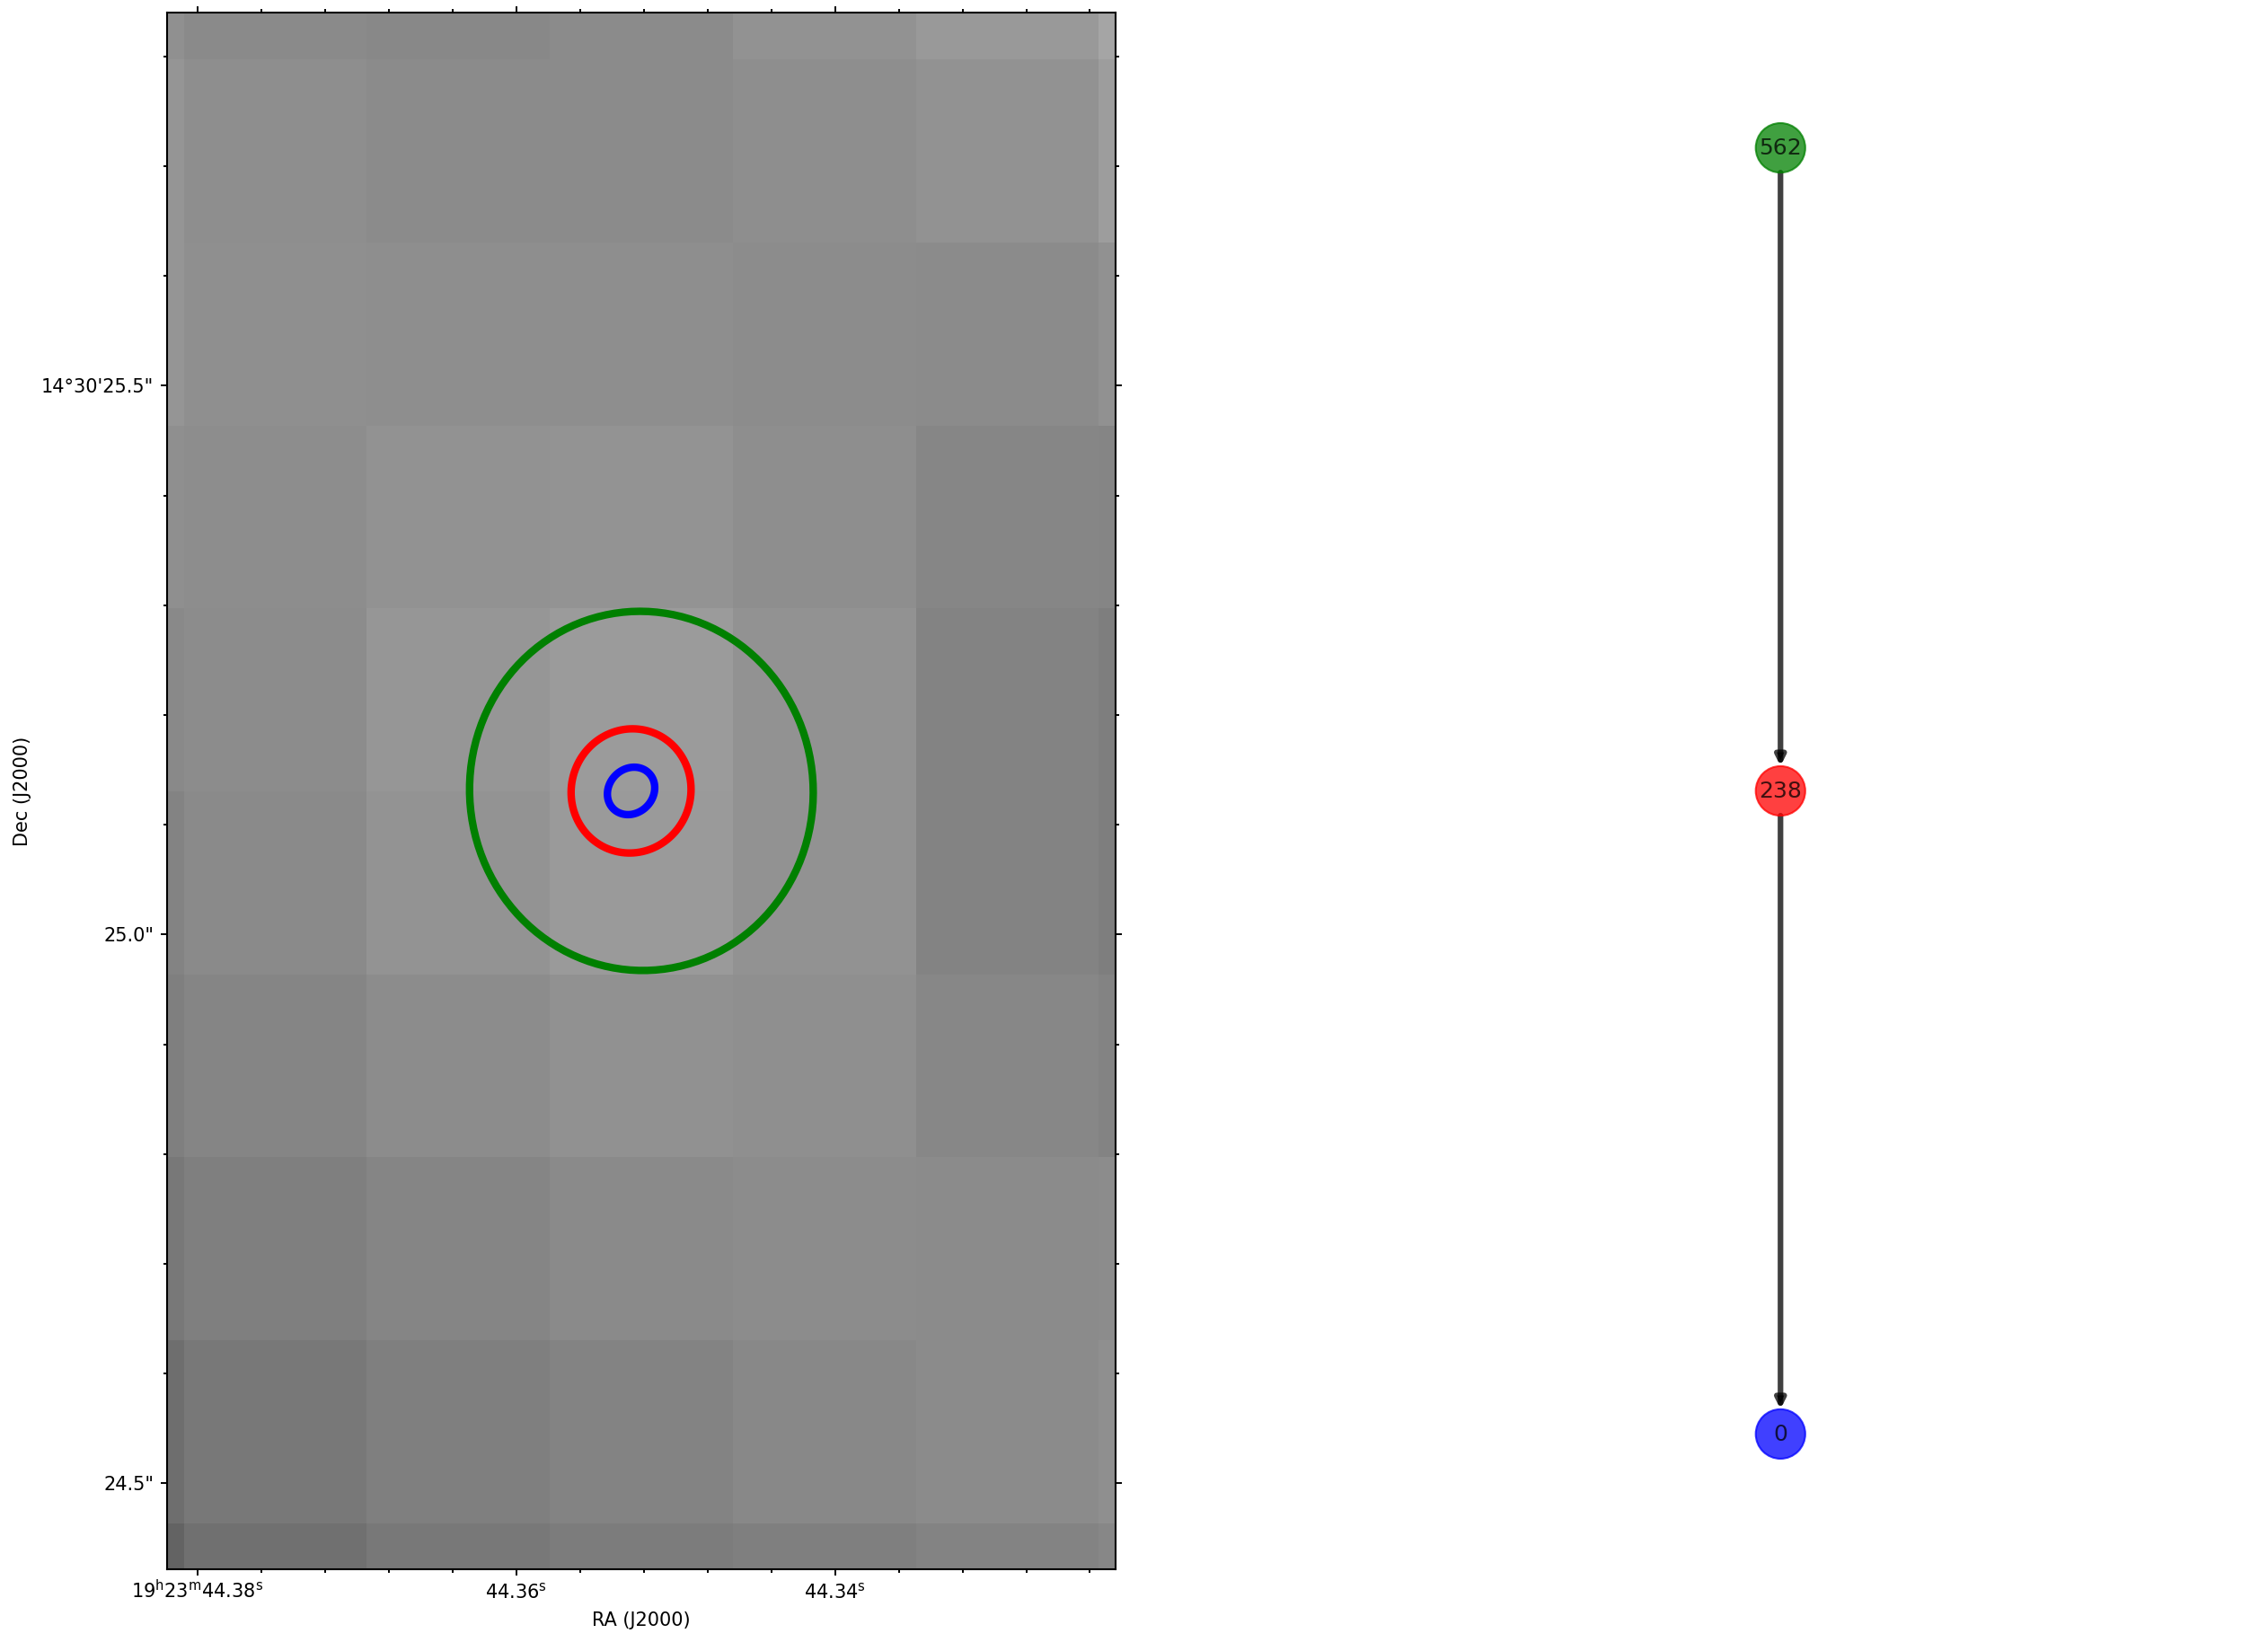

In [23]:
image = dataset._data['2700AU'].fits_img
fig = network.structures[0].plot(image)

In [24]:
plotter.InspectNetwork(network)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


INFO: Auto-setting vmin to  9.342e+19 [aplpy.core]
INFO: Auto-setting vmax to  2.230e+24 [aplpy.core]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


1


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


...

53
seen component number 53
recentering in (np.float64(290.9327053325871), np.float64(14.505793199432597)) at radius 0.00017418103777434233
INFO: Auto-setting vmin to  1.574e+21 [aplpy.core]
INFO: Auto-setting vmax to  8.130e+23 [aplpy.core]
INFO: Auto-setting vmin to  1.793e+20 [aplpy.core]
INFO: Auto-setting vmax to  2.364e+24 [aplpy.core]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


39
seen component number 39
recentering in (np.float64(290.9328533084972), np.float64(14.505772088038622)) at radius 0.00013766644927443007


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


14
seen component number 14
recentering in (np.float64(290.9328041000002), np.float64(14.505595700000002)) at radius 0.00018061233293035207


<Figure size 2400x2400 with 0 Axes>

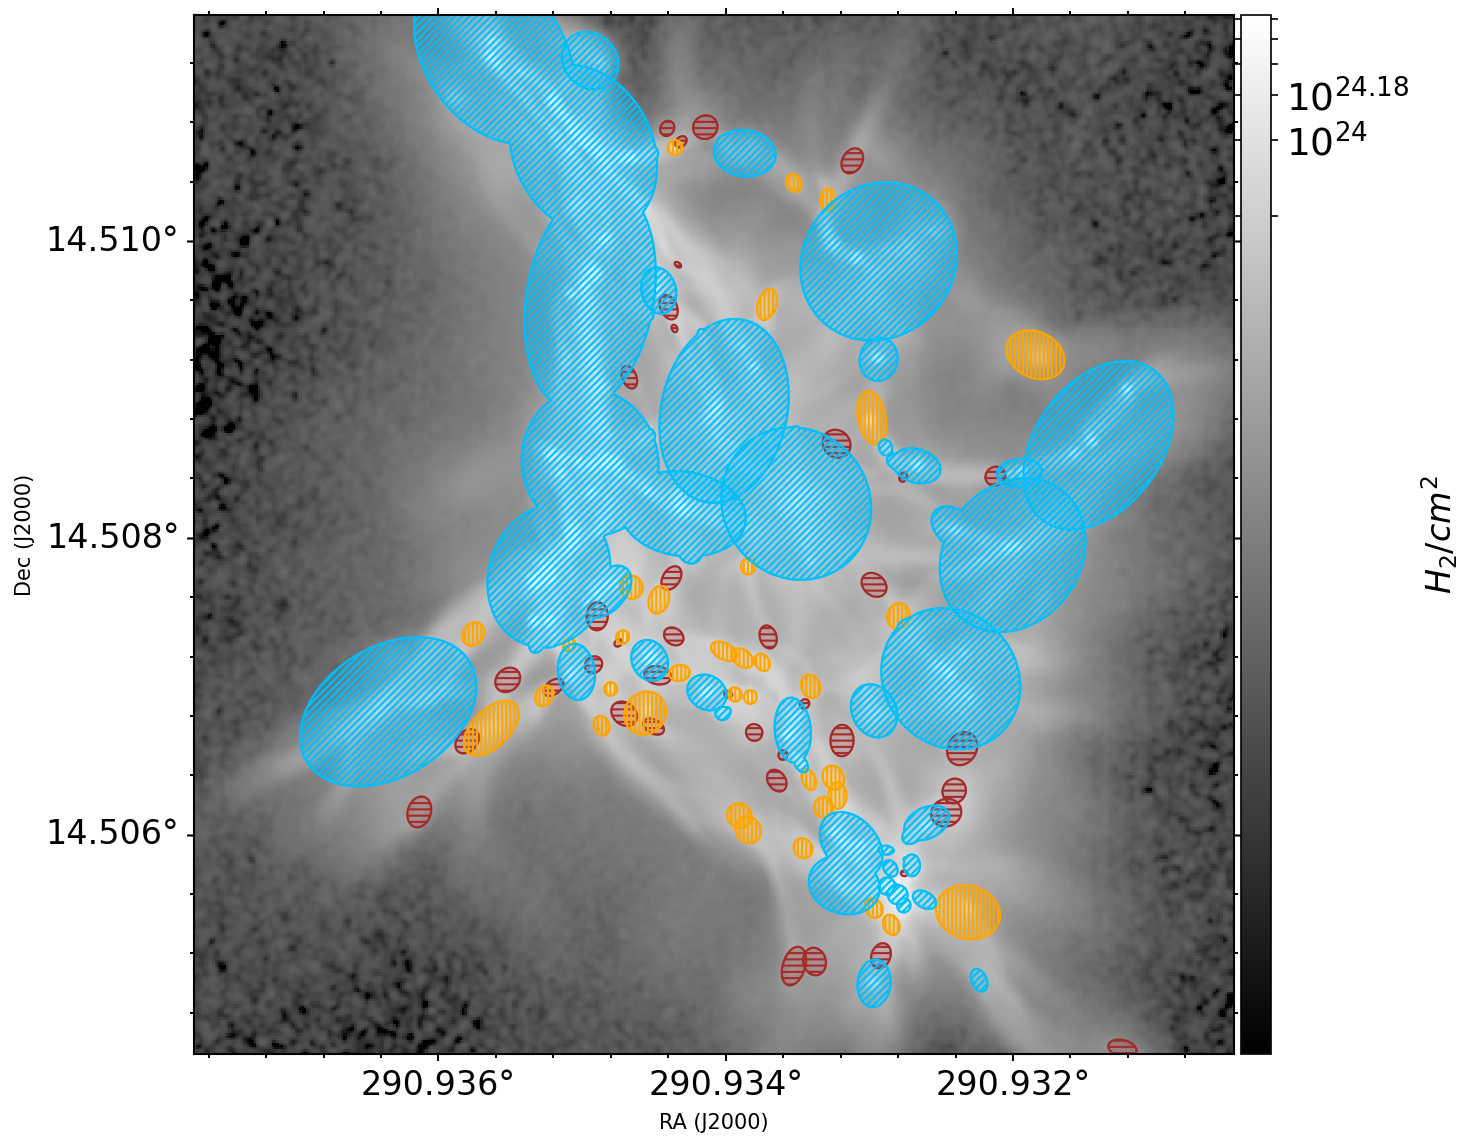

In [25]:
import aplpy
from astropy.io import fits
from astropy.wcs import WCS

####### Figures Definition
FIGURE = plt.figure(figsize=(16, 16))


colors = ["m", "g", "b", "r", "c"]

hdu = fits.open('benchmark/fits/column_density_01500_z.+.noise.mul1e23.r900au.bor-4650.rs333au.fits')

img = hdu[0].data
hdr = hdu[0].header


vmin = np.nanpercentile(np.where(img>0, img, np.nan), 0.1)
vmax = np.nanpercentile(np.where(img>0, img, np.nan), 99.9)

new_fits = fits.PrimaryHDU(data=img, header=hdr)


fig = aplpy.FITSFigure(new_fits)

#fig.show_colorscale(cmap='Greys', vmin=vmin, vmax=vmax, stretch='log') 
fig.show_grayscale(vmin=vmin, vmax=vmax, stretch='log') 

fig.add_colorbar()
fig.colorbar.set_font(size=12)
fig.colorbar.set_axis_label_font(size=16)

ticks = 10**np.arange(np.log10(vmin), np.log10(vmax))
fig.colorbar.show(log_format=True)
fig.colorbar.set_axis_label_text("$H_2 / cm^2$")
fig.colorbar.set_font(size=18)


fig.tick_labels.set_xformat('dd.ddd')
fig.tick_labels.set_yformat('dd.ddd')
fig.tick_labels.set_font(size=16)


# structures
modes = ['ISOLATED', 'LINEAR', 'HIERARCHICAL']
colors = ['brown',  'orange', 'deepskyblue'] #= azure
hatches = ['----', '||||||', '///////']
alphas = [0.2, 0.2, 0.2]



for mode, color, hatch, alpha in zip(modes, colors, hatches, alphas):
    polygons = structure_table["polygon"][structure_table["mode"] == mode]
    comp = structure_table["component"][structure_table["mode"] == mode]
    PTS = []
    for i, poly in enumerate(polygons):
        node = sorted(comp.values[i].nodes)[-1]
        x, y = poly.exterior.xy
        PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

    fig.show_polygons(PTS, facecolor=color, edgecolor="none", alpha=alpha)
    fig.show_polygons(PTS, facecolor="none", edgecolor=color, hatch=hatch)
    fig.show_polygons(PTS, facecolor="none", edgecolor=color, alpha=0.5)


#fig.scalebar.show()  # length in degrees
plt.savefig('Struct_Repartition.pdf')

# Fractalité et N vs R

mean prod. y axis = [np.float64(3.7170329670329667), np.float64(4.035714285714286), np.float64(2.513824884792627), np.float64(1.1428571428571428), np.float64(1.0)]


Text(0, 0.5, '$<N_{tot}/N_{tot}^0>$')

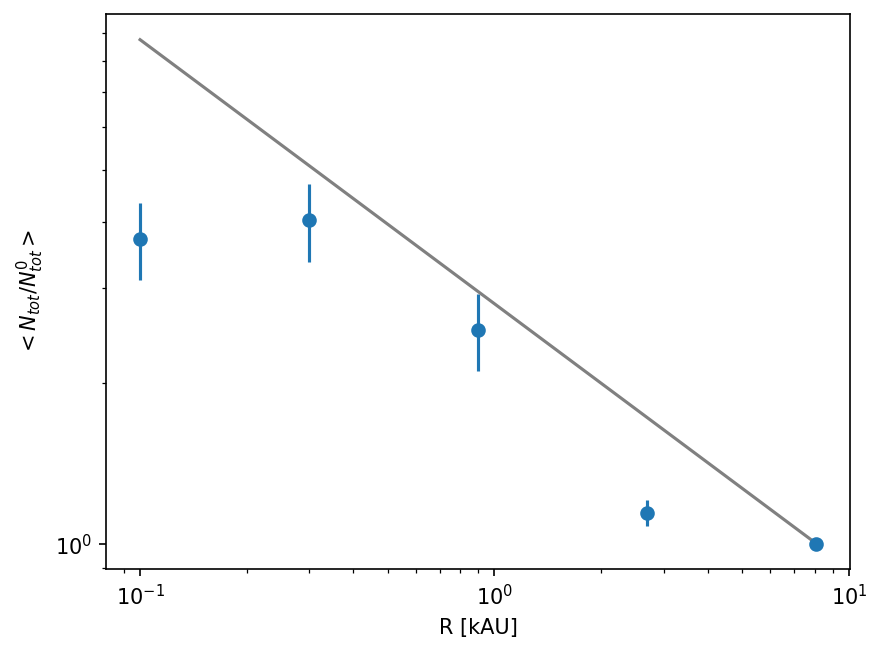

In [26]:
distance = network.data[-1].distance
x, meany, stdy = plotter.getFragCurve(network, distance, mode = "HIERARCHICAL")

print("mean prod. y axis =", meany)

fig, ax = plt.subplots()

x_kau = x / 1000
ax.errorbar(x_kau, meany, stdy, np.zeros_like(x), "o")

fractality = np.mean(structure_table["fractality"][structure_table["mode"] == "HIERARCHICAL"])
fractality_arr = np.ones_like(x) * fractality
exponent = -(np.log(fractality_arr)/np.log(2))

ax.plot(x_kau, (x / max(x))**exponent, "-", color="grey")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("R [kAU]")
ax.set_ylabel("$<N_{tot}/N_{tot}^0>$")

# Uncertainties with virtual nodes

In [27]:
nb_node = []

fractal = []
suspicious = []
fractal_160conv = []
fractal_geom = []

fractal_corr = []
missed_corr = []

n_core_lin = 0
n_core_iso = 0
n_core_hier = 0
idx = 0
number_h = 0
number_l = 0
number_i = 0
number_iso43 = 0
for s in network.structures:
    #print(s.component.in_degree)
    if s.mode.name == "HIERARCHICAL":# or s.mode.name == "LINEAR":
        if idx not in suspicious:
            fractal_corr.append(s.fractality)
            missed_corr.append(s.percmissed)
            number_h += 1
            n_core_hier += len(s.component)
        fractal.append(s.fractality)
        idx += 1
        nb_node.append(len(s.component))
    if s.mode.name == "LINEAR":
        number_l += 1
        n_core_lin += len(s.component)
    if s.mode.name == "ISOLATED":
        number_iso43 += 1
        number_i += 1
        n_core_iso += len(s.component)

print("number of hierarchical cores = ", n_core_hier)
print("number of linear cores = ", n_core_lin)
print("number of isolated cores = ", n_core_iso)
print("number of hierarchical structures = ", number_h)
print("number of isolated structures with scale 0.43 = ", number_iso43)
print("number of linear structures = ", number_l)
print("number of isolated structures = ", number_i) 
print("------------------------------------------------\n")

#print(fractal)
print(f"mean = {np.mean(fractal):.2f} +/- {np.std(fractal):.2f}")
print(f"median = {np.median(fractal):.2f}")

fractality_corr_carences = ( np.median(fractal_corr) * (1+0.2) + np.median(fractal))/2
dfractality_corr_carences = fractality_corr_carences - np.median(fractal)

print(f"carences corr = {fractality_corr_carences:.2f}")

phi2D = np.log(fractality_corr_carences) / np.log(2)
dphi2D = dfractality_corr_carences / fractality_corr_carences

print(f"phi2D = {phi2D:.2f} +/- {dphi2D:.2f}")

f = -0.3
projection_error = -0.3
dprojection_error = 0.05

d1 = (dphi2D/(1 + projection_error))**2
d2 = (phi2D / (1 + projection_error)**2 * dprojection_error) **2

phi3D, dphi3D = phi2D / (1 + f), np.sqrt(d1 + d2)

print(f"phi3D = {phi3D:.2f} +/- {dphi3D:.2f}")
print(f"F_3D = {np.exp(phi3D*np.log(2)):.2f}")
print(f"Number of node in the Hierarchical structures come from {np.min(nb_node)} to {np.max(nb_node)}")

number of hierarchical cores =  670
number of linear cores =  88
number of isolated cores =  39
number of hierarchical structures =  32
number of isolated structures with scale 0.43 =  39
number of linear structures =  35
number of isolated structures =  39
------------------------------------------------

mean = 1.41 +/- 0.22
median = 1.42
carences corr = 1.56
phi2D = 0.64 +/- 0.09
phi3D = 0.91 +/- 0.15
F_3D = 1.88
Number of node in the Hierarchical structures come from 3 to 350


In [28]:
virtual = utility.virtualNodes(network.network, network.levels)

In [29]:
network_virtualfill = analyse.Network(analyse.DataSet(network.data), min_overlap=network.min_overlap, graph=virtual)

utility.fractality(network_virtualfill.network)

clumps = utility.toDataFrame(network_virtualfill.network)

network_virtualfill.extractStructures()
structure_table_virtual = network_virtualfill.getStructuresTable()

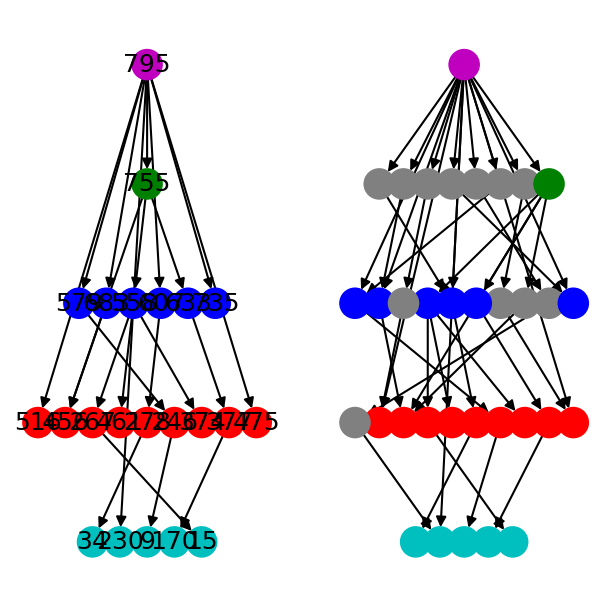

In [30]:
import networkx as nx
# Check virtuals

hierarchical_structures = structure_table["component"][structure_table["mode"] == "HIERARCHICAL"]
hierarchical_structures_virtuals = structure_table_virtual["component"][structure_table_virtual["mode"] == "HIERARCHICAL"]

idx = 2
struct = hierarchical_structures.array[idx]
struct_virtual = hierarchical_structures_virtuals.array[idx]

colors = ["m", "g", "b", "r", "c"][::-1]
scales = network.levels
colors = {str(scale):color for color, scale in zip(colors, scales)}

color = []
for _, b in struct.nodes("_beam"):
    if b != 2.:
        color.append(colors[str(b)])
    else:
        color.append("grey")

color_virtual = []
for node, b in struct_virtual.nodes("_beam"):
    if b != 2. and struct_virtual.nodes[node]["_Kind"].name != "VIRTUAL":
        color_virtual.append(colors[str(b)])
    elif b ==2:
        color_virtual.append("k")
    else:
        color_virtual.append("grey")
                
figure, axs = plt.subplots(ncols=2, figsize=(5, 5))

# without virtuals
pos = nx.multipartite_layout(struct, subset_key="_level", align="horizontal")
nx.draw(struct, pos, ax=axs[0], node_color=color, node_size=200, with_labels=True)

# with virtuals
pos = nx.multipartite_layout(struct_virtual, subset_key="_level", align="horizontal")
nx.draw(struct_virtual, pos, ax=axs[1], node_color=color_virtual, node_size=200, with_labels=False)

median with virtual nodes = 1.4574
median without virtual nodes = 1.4161


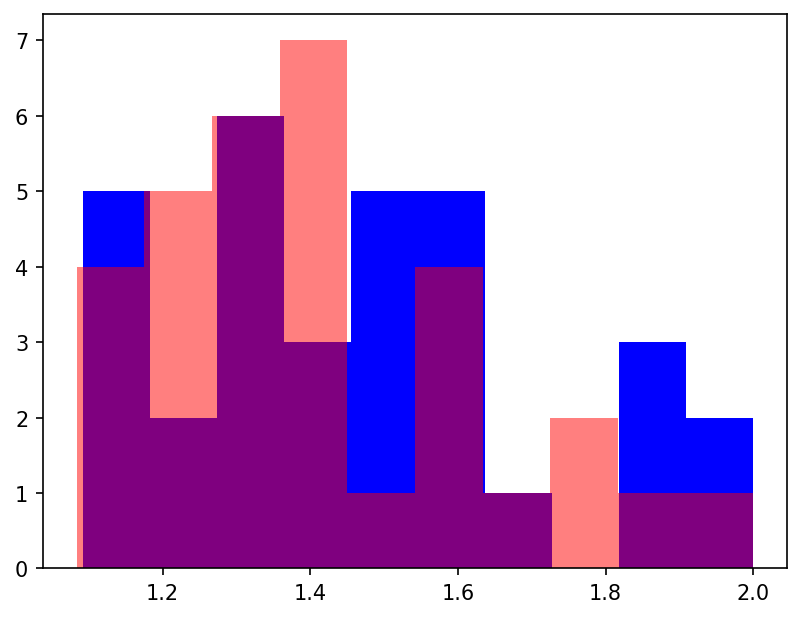

In [31]:
plt.hist(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"], color="b")
plt.hist(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"], color="r", alpha=0.5)

print(f"median with virtual nodes = {np.median(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"]):.4f}")
print(f"median without virtual nodes = {np.median(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"]):.4f}")

In [32]:
def fragmentation_rate2D(fractality, uncertainty):
    return np.log(fractality)/np.log(2), uncertainty/fractality/np.log(2)

for structure_real, structure_hole in zip(network.structures, network_virtualfill.structures):

    fractality = (structure_real.fractality + structure_hole.fractality)/2
    uncertainty = abs(structure_real.fractality - structure_hole.fractality)/2
    
    phi, dphi = fragmentation_rate2D(fractality, uncertainty)

    structure_real.fragmentation_rate = phi, dphi
    

# Mass transfer

In [34]:
from  analysis import multiscale_structures

hierachical_nodes = []
for s in structure_table['component'][structure_table['mode'] == "HIERARCHICAL"]:
    hierachical_nodes.extend(list(s))
def find_structure_with_node(node, network):
    for i, structure in enumerate(network.structures):
        if node in structure.component:
            return i
    return None


def rescaling(Mfrom, Mto, Scaleid_from, Scaleid_to):
    coef = 1 / ( np.log(Scaleid_from/Scaleid_to) / np.log(2) ) 
    Matt = ( (Mto/Mfrom)**coef ) * Mfrom
    return Matt 

def InjectionMassRate(Ri, Rii, Mi, Mii):
    lnMtot = np.log(Mii) - np.log(Mi)
    lnR = np.log(Rii) - np.log(Ri)
    return -lnMtot/lnR  


Q = {}

for i in range(len(network.structures)):
    if network.structures[i].mode.name == "HIERARCHICAL":
        L = np.array(list(network.structures[i].component.in_edges.keys()), dtype = int)
        for j in L:
            parent = j[0]
            child = j[1]
            try:
                Q[parent].append([child, clumps['_beam'][child] , clumps['_M'][child], clumps['_beam'][parent] ,clumps['_M'][parent] ])
            except KeyError:
                Q[parent] = [[child, clumps['_beam'][child] , clumps['_M'][child], clumps['_beam'][parent] ,clumps['_M'][parent] ]]


mass_transfer_efficiency = []
mass_partition = []
dominant_child_mass = []

for key, value in Q.items():
    total_child_flux = 0
    for i in value:
        total_child_flux += rescaling(i[4], i[2], i[3], i[1])
    child_sorted = sorted(value, key=lambda x: rescaling(x[4], x[2], x[3], x[1]), reverse=True)
    mass_transfer_efficiency.append(total_child_flux / child_sorted[0][4] * 100)
    if len(child_sorted) >= 2:
        dominant_child_mass.append(rescaling(child_sorted[0][4], child_sorted[0][2], child_sorted[0][3], child_sorted[0][1]) / child_sorted[0][4] * 100)
    
        mass_partition.append(rescaling(child_sorted[0][4], child_sorted[0][2], child_sorted[0][3], child_sorted[0][1]) / rescaling(child_sorted[1][4], child_sorted[1][2], child_sorted[1][3], child_sorted[1][1]))

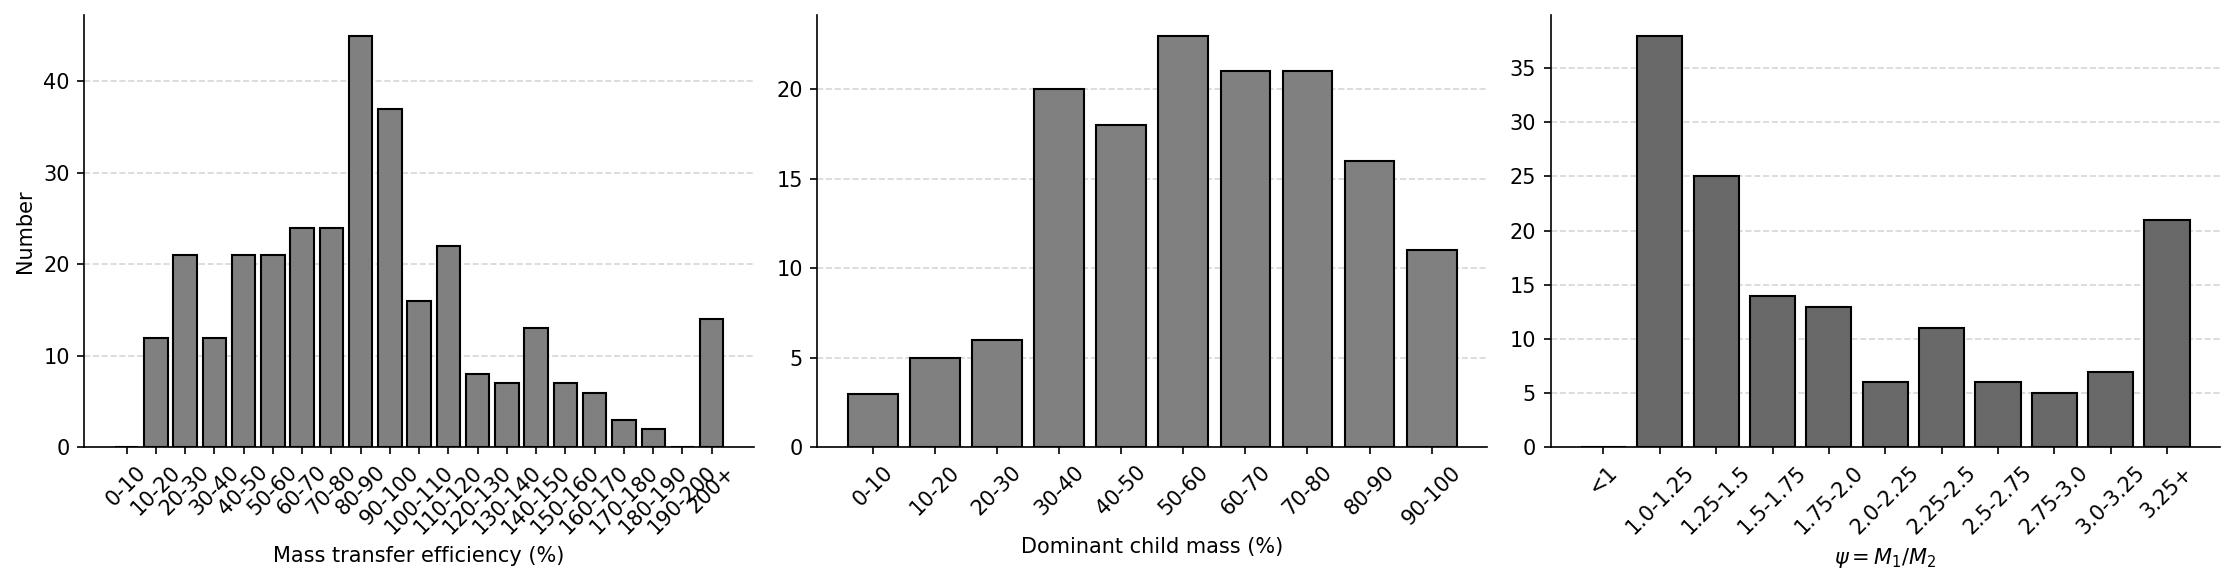

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)



values = np.array(mass_transfer_efficiency)


max_val = 200

bins = np.r_[np.arange(0, max_val + 10, 10), np.inf]  # 0-10, ..., 90-100, 100+
counts, _ = np.histogram(values, bins=bins)
labels = [f"{i}-{i+10}" for i in range(0, int(max_val), 10)] + [f"{int(max_val)}+"]




axes[0].bar(labels,counts,color='gray',edgecolor='black',width=0.8)
axes[0].set_xlabel('Mass transfer efficiency (%)')
axes[0].set_ylabel('Number')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

values = np.array(dominant_child_mass)

bins = np.r_[np.arange(0, 110, 10)]  # 0-10, ..., 90-100, 100+
counts, _ = np.histogram(values, bins=bins)
labels = [f"{i}-{i+10}" for i in range(0, 100, 10)]

axes[1].bar(labels, counts, color='gray', edgecolor='black', width=0.8)
axes[1].set_xlabel('Dominant child mass (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

values = np.array(mass_partition)

bins = np.r_[-np.inf, np.arange(1, 3.5, 0.25), np.inf]  # 0-10, ..., 90-100, 100+
counts, _ = np.histogram(values, bins=bins)
labels = ['<1'] + [f"{i}-{i+0.25}" for i in np.arange(1, 3.25, 0.25)] + ["3.25+"]

axes[2].bar(labels, counts, color='dimgray', edgecolor='black', width=0.8)
axes[2].set_xlabel(r'$\psi = M_1 / M_2$')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[2].set_axisbelow(True)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('Mass_statistics_AA.pdf', bbox_inches='tight')
plt.show()